## WEEK 10
#### Visualisations - df_arabia_cleaned dataset
#### Yiscah Mark

#### I load the dataset in this cell. The dataset is already clean. Because there are some funny columns with chinese letters I made a new dataset called df_clean of just the columns that I want to use for the visualizations. I printed the first few lines to view the data. I used the .columns.tolist() function to get the exact column names to be able to make a new dataset with those specific columns. 

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# 1. Load and Clean Data
df = pd.read_csv('df_arabica_clean.csv')

# 2. Select Columns (Using exact matches from your provided list)
cols = ['Country of Origin', 'Aroma', 'Flavor', 'Acidity', 'Body', 'Balance', 'Total Cup Points', 'Color']
df_clean = df[cols].dropna()

# Data Prep for Bar Chart
top_countries = df_clean['Country of Origin'].value_counts().nlargest(10)
# Data Prep for Pie Chart
color_counts = df_clean['Color'].value_counts()
df_clean.head()

,Country of Origin,Aroma,Flavor,Acidity,Body,Balance,Total Cup Points,Color
0,Colombia,8.58,8.50,8.58,8.25,8.42,89.33,green
1,Taiwan,8.50,8.50,8.00,7.92,8.25,87.58,blue-green
2,Laos,8.33,8.42,8.17,7.92,8.17,87.42,yellowish
3,Costa Rica,8.08,8.17,8.25,8.17,8.08,87.17,green
4,Colombia,8.33,8.33,8.25,7.92,7.92,87.08,yellow-green


In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'ID', 'Country of Origin', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number of Bags', 'Bag Weight', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Owner', 'Variety', 'Status', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Total Cup Points', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Color', 'Category Two Defects', 'Expiration', 'Certification Body', 'Certification Address', 'Certification Contact']


#### My first pie chart of bean colors had many different categories. I read in the book that it is too much. Instead in the following cell I take out the top two columns and group all the rest to one group called "other".

In [13]:
# 1. Group smaller categories into 'Other'
color_counts = df_clean['Color'].value_counts()
# Keep the top 2 categories and group the rest
top_n = 2
other_sum = color_counts[top_n:].sum()
color_counts_simplified = color_counts[:top_n].copy()
color_counts_simplified['Other'] = other_sum


#### These are my visualizations using Seaborn. I have a pie chart that shows the bean colors, grouped as mentioned above. The bar chart compares the count by country of origin, only including the top 10. My next visualization shows the number of cup points in a histogram with bars and a line going through to show the distribution curve. My last chart, a heat map shows the sensory correlation of the coffee, using darker and lighter shades of yellow/brown to show the values.

/tmp/ipykernel_236/3682272364.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0, 1], palette="viridis")


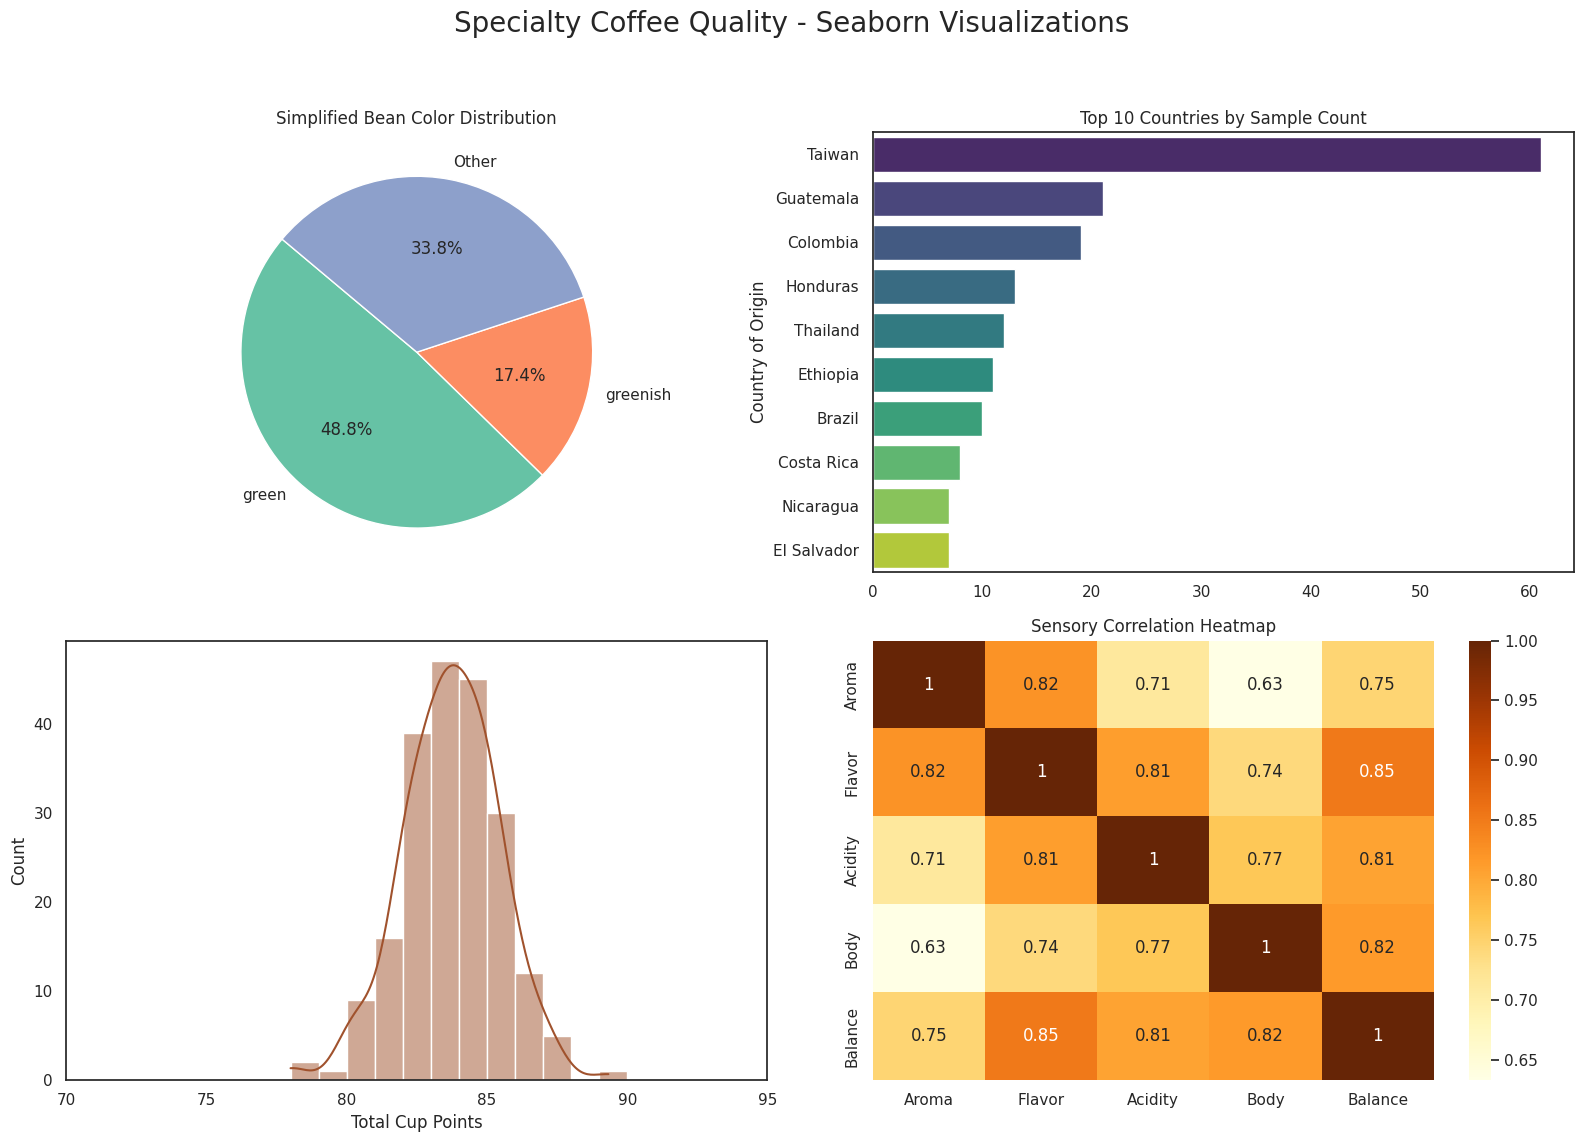

In [18]:
# --- SEABORN VISUALIZATIONS ---
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Specialty Coffee Quality - Seaborn Visualizations', fontsize=20)


# 1. Pie Chart
axes[0, 0].pie(color_counts_simplified, 
               labels=color_counts_simplified.index, 
               autopct='%1.1f%%', 
               colors=sns.color_palette("Set2"),
               startangle=140)
axes[0, 0].set_title("Simplified Bean Color Distribution")
# 2. Bar Chart
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0, 1], palette="viridis")
axes[0, 1].set_title("Top 10 Countries by Sample Count")

# 3. Histogram with KDE Overlay
bin_range = np.arange(70, 96, 1) 

sns.histplot(df_clean['Total Cup Points'], 
             bins=bin_range, 
             kde=True, 
             ax=axes[1, 0], 
             color="sienna")

# Keep it 'zoomed in' but with clean labels
axes[1, 0].set_xlim(70, 95)
axes[1, 0].set_xticks([70, 75, 80, 85, 90, 95])
# 4. Heatmap
corr = df_clean[['Aroma', 'Flavor', 'Acidity', 'Body', 'Balance']].corr()
sns.heatmap(corr, annot=True, cmap="YlOrBr", ax=axes[1, 1])
axes[1, 1].set_title("Sensory Correlation Heatmap")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



#### The following cell uses matplotlib to make the same visualizations as above. The output is very similar, though not exact. The color in the bar chart changes in seaborn and there are no labels in the heatmap of matplotlib. Overall, the results are pretty similar looking, I think seaborn is a little more sophisticated.

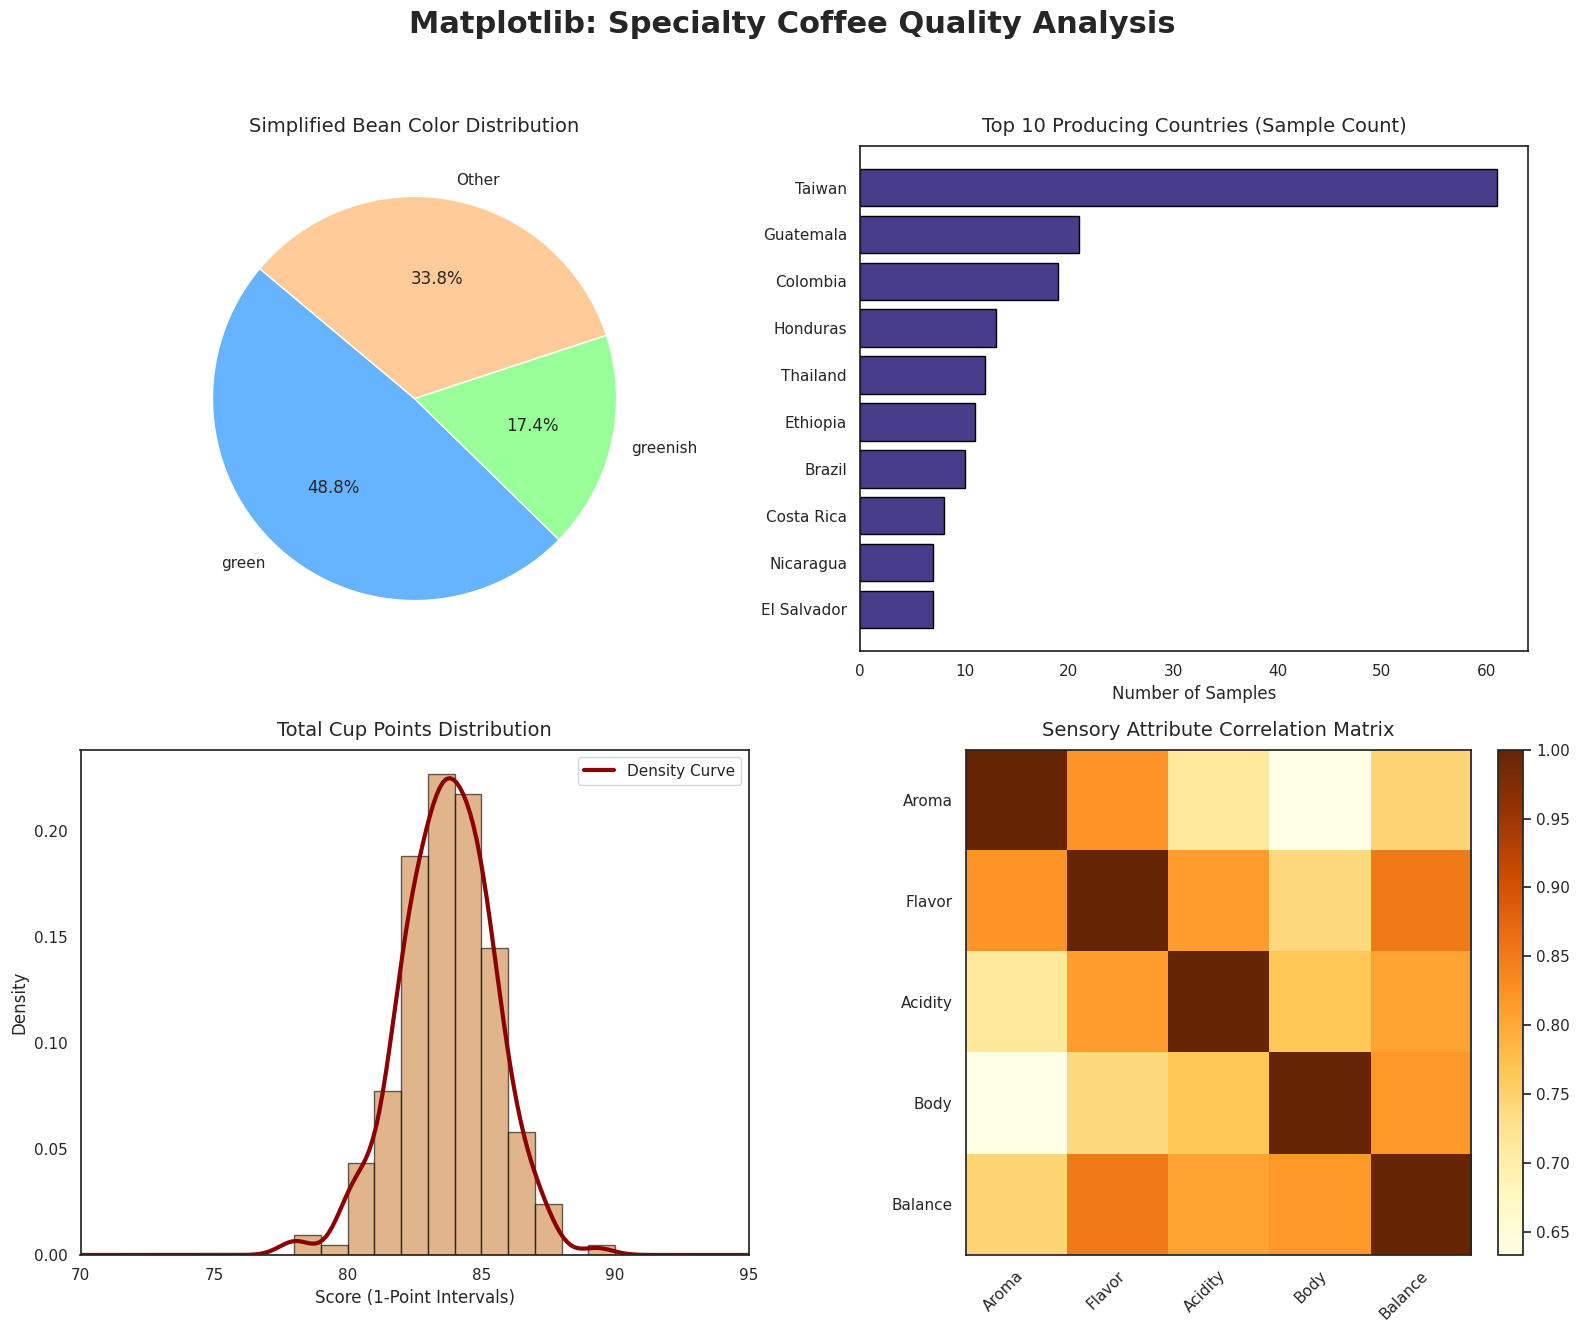

In [23]:

# --- MATPLOTLIB VISUALIZATIONS ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Matplotlib: Specialty Coffee Quality Analysis', fontsize=22, fontweight='bold', y=0.98)

# --- PIE CHART ---
axes[0, 0].pie(color_counts_simplified, labels=color_counts_simplified.index, 
               autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ffcc99'])
axes[0, 0].set_title('Simplified Bean Color Distribution', fontsize=14, pad=10)

# --- BAR CHART ---
axes[0, 1].barh(top_countries.index, top_countries.values, color='darkslateblue', edgecolor='black')
axes[0, 1].invert_yaxis()
axes[0, 1].set_title('Top 10 Producing Countries (Sample Count)', fontsize=14, pad=10)
axes[0, 1].set_xlabel('Number of Samples')

# --- HISTOGRAM WITH DISTRIBUTION CURVE ---
data = df_clean['Total Cup Points'].values
bin_range = np.arange(70, 96, 1) # 1-point intervals
axes[1, 0].hist(data, bins=bin_range, density=True, alpha=0.6, color='peru', edgecolor='black')

# Manual KDE Calculation
kde = gaussian_kde(data)
x_range = np.linspace(70, 95, 200)
axes[1, 0].plot(x_range, kde(x_range), color='darkred', linewidth=3, label='Density Curve')

axes[1, 0].set_xlim(70, 95)
axes[1, 0].set_xticks([70, 75, 80, 85, 90, 95])
axes[1, 0].set_title('Total Cup Points Distribution', fontsize=14, pad=10)
axes[1, 0].set_xlabel('Score (1-Point Intervals)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# --- HEATMAP ---
im = axes[1, 1].imshow(corr, cmap='YlOrBr')
axes[1, 1].set_title('Sensory Attribute Correlation Matrix', fontsize=14, pad=10)

# Set ticks and labels
axes[1, 1].set_xticks(np.arange(len(corr.columns)))
axes[1, 1].set_yticks(np.arange(len(corr.columns)))
axes[1, 1].set_xticklabels(corr.columns)
axes[1, 1].set_yticklabels(corr.columns)

# Rotate labels for eloquence
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Final Layout Adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### WRITE-UP
#### My data is all about coffee. The country of origin, color, sensory, and other variables. Each of my visualizations zooms in on another factor or detail of the set, but my overall data statement is "What makes coffee high-quality?"
#### As I mentioned above, I grouped the third-most-common with all the other less common colors to have only three categories. We can easily see that almost one half of the beans are green, a little less than one fifth are "greenish", and the rest, about one third, are another color. The pie chart was terrific for showing my now-few categories in relation to each other. 
#### I rotated my bar chart so the labels don't overlap. With seaborn, I used a color scale to color the bars based on their proportional areas. The colors are a pretty clear scale, but an extra to make it pretty, because it does not show more information than is on the graph beforehand. The bar chart is great in this case, as it makes comparisons between the top ten countries easy.
#### My Distribution graph shows the count of points distributed per cup, in the very appropriate color of light brown. In this week's reading, it was mentioned that the axis scale should be in increments of 1, 5, or 10. In my case, I first set it to random within the data's range. I went back and switched it to a scale of one bin per number, with a label every five. 
#### My sensory correlation heatmap shows the correlation between each sensory and the others. There is a very clear scale on the side that shows what each color represents. This scale is good to use because it is very clear, with a deep brown/yellow at one end that gets lighter and softer as the correlation lessens. As always, on a correlation map, there is a diagonal line that shows each category's correlation with itself as 1. A correlation map was great for showing the relationship and blend of sensory attributes in coffee.
#### I learned a lot about how visualizations can really tell a story. Also, not all visuals are great for all data. Each dataset has a specific visual that conveys its clearest message.
